In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np


In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
## performance: per seed performance
## lats_performance: avg over seed performance at the end of training
## last_performance_unnormalized: same as last_performance but without normalization
## max_performance: average over seeds (how?) max performance achieved during training (presumably)

# 1. Normalization

In [4]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(
    lambda g: (g["performance"] - g["_seed_avg"].min()) / (g["_seed_avg"].max() - g["_seed_avg"].min() + 1e-8)
)
data.drop(columns=["_seed_avg"], inplace=True)

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_35073/355322313.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(


# 2. THC 

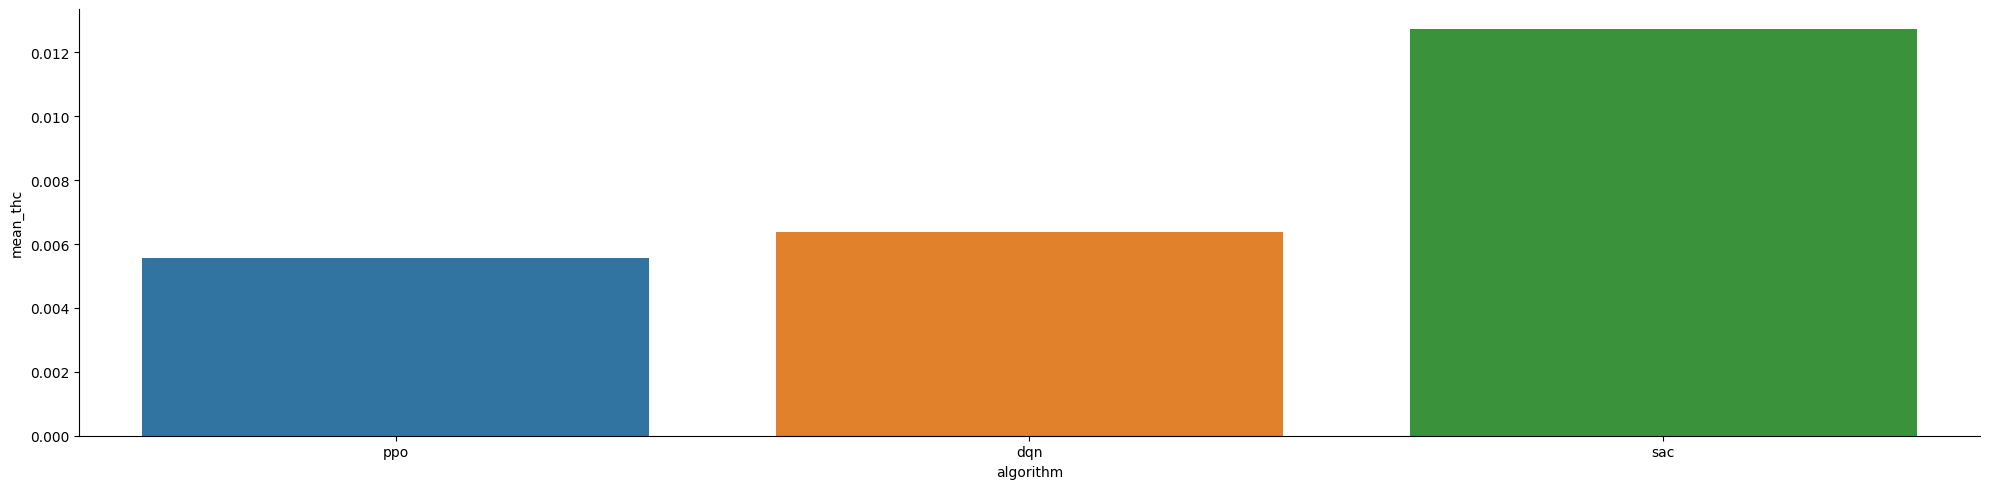

In [5]:
# THC metric
ranks = []
config_ids = []
environments = []
algorithms = []
for env in envs:
    for algo in algos:
        subset = data[data["algorithm"]==algo]
        env_subset = subset[subset["env_name"]==env]
        if len(env_subset) == 0:
            continue
        mu = env_subset.groupby("config_id")["last_performance"].mean()
        sigma = env_subset.groupby("config_id")["last_performance"].std(ddof=0)
        
        def binary_search_upper(arr, target):
            low, high = 0, len(arr)
            while low < high:
                mid = (low + high) // 2
                if arr[mid] > target:
                    high = mid
                else:
                    low = mid + 1
            return low - 1

        def binary_search_lower(arr, target):
            low, high = 0, len(arr)
            while low < high:
                mid = (low + high) // 2
                if arr[mid] < target:
                    low = mid + 1
                else:
                    high = mid
            return low

        r_prime = np.argsort(mu + sigma)[::-1]  # Descending order (higher is better)
        mu_prime = mu.iloc[r_prime]
        sigma_prime = sigma.iloc[r_prime]
        lower_bounds = mu_prime - sigma_prime
        upper_bounds = mu_prime + sigma_prime
            
        for config_id in subset["config_id"].unique():
            upper_bound_j = mu[config_id] + sigma[config_id]
            u = binary_search_upper(lower_bounds, upper_bound_j)

            lower_bound_j = mu[config_id] - sigma[config_id]
            l = binary_search_lower(upper_bounds, lower_bound_j)
            config_ids.append(config_id)
            ranks.append((u + l) / 2.0)
            environments.append(env)
            algorithms.append(algo)

thc_data = pd.DataFrame({
    "env_name": environments,
    "algorithm": algorithms,
    "config_id": config_ids,
    "thc_rank": ranks
})
thc_data["ptp"] = thc_data.groupby(["env_name", "algorithm"])["thc_rank"].transform(lambda x: x.max() - x.min())
thc_data["normed_ptp"] = thc_data["ptp"] / thc_data.groupby(["env_name", "algorithm"])["thc_rank"].transform("sum")
thc_data["thc_score"] = thc_data.groupby(["env_name", "algorithm"])["normed_ptp"].transform("mean")
thc_data["mean_thc"] = thc_data.groupby(["algorithm"])["thc_score"].transform("mean")
sns.catplot(data=thc_data, x="algorithm", y="mean_thc", hue="algorithm", kind="bar", aspect=4)


# 3. Other Metrics

In [6]:
def get_performance_arrays(
        alg_subset,
        perf_col: str
        ):
    alg_performances = []

    for env in alg_subset["env_name"].unique():

        env_performances = []
        
        for config_id in alg_subset["config_id"].unique():

            env_config_subset = alg_subset[(alg_subset["env_name"]==env) & (alg_subset["config_id"]==config_id)]
            env_performances.append(env_config_subset[perf_col].values)
        
        alg_performances.append(env_performances)
    
    return alg_performances


In [7]:
def tuned_score_per_env(x):
    """
    x: list[list[list[float]]] - shape (envs, configs, seeds)
    
    Computes: avg(max(avg(x, axis=-1), axis=-1), axis=-1) - max(avg(avg(x, axis=-1), axis=0), axis=-1)
    
    First term: For each env, find the best config (by seed-averaged performance), then average across envs
    Second term: Average across envs first, then find the best config
    """
    # avg(x, axis=-1) -> average over seeds: list[list[float]] shape (envs, configs)
    seed_avg = [[np.mean(seeds) for seeds in env] for env in x]
    
    # First term: avg(max(seed_avg, axis=-1), axis=-1)
    # max over configs per env, then average over envs
    max_per_env = [max(env) for env in seed_avg]
    first_term = np.mean(max_per_env)
    
    return first_term


def adkins_phi(x):
    """
    x: list[list[list[float]]] - shape (envs, configs, seeds)
    
    Computes: avg(max(avg(x, axis=-1), axis=-1), axis=-1) - max(avg(avg(x, axis=-1), axis=0), axis=-1)
    
    First term: For each env, find the best config (by seed-averaged performance), then average across envs
    Second term: Average across envs first, then find the best config
    """
    # avg(x, axis=-1) -> average over seeds: list[list[float]] shape (envs, configs)
    seed_avg = [[np.mean(seeds) for seeds in env] for env in x]
    
    # First term: avg(max(seed_avg, axis=-1), axis=-1)
    # max over configs per env, then average over envs
    max_per_env = [max(env) for env in seed_avg]
    first_term = np.mean(max_per_env)
    
    # Second term: max(avg(seed_avg, axis=0), axis=-1)
    # average over envs (axis=0), then max over configs
    n_configs = len(seed_avg[0])
    avg_over_envs = [np.mean([seed_avg[env][config] for env in range(len(seed_avg))]) for config in range(n_configs)]
    second_term = max(avg_over_envs)
    
    return first_term - second_term



def transfer_metric(x):
    """
    x: list[list[list[float]]] - shape (envs, configs, seeds)
    
    Computes: avg(max(avg(x, axis=-1), axis=-1), axis=-1) - max(avg(avg(x, axis=-1), axis=0), axis=-1)
    
    First term: For each env, find the best config (by seed-averaged performance), then average across envs
    Second term: Average across envs first, then find the best config
    """
    # avg(x, axis=-1) -> average over seeds: list[list[float]] shape (envs, configs)
    seed_avg = [[np.mean(seeds) for seeds in env] for env in x]
    
    # First term: avg(max(seed_avg, axis=-1), axis=-1)
    # max over configs per env, then average over envs
    max_per_env = [max(env) for env in seed_avg]
    first_term = np.mean(max_per_env)
    
    # Second term: 1/M sum_m seed_avg[m][opt_j(m)]
    # where opt_j(m) = argmax_{m' != m, j} seed_avg[m'][j]
    M = len(seed_avg)
    second_term_values = []
    for m in range(M):
        # Find the best (m', j) pair excluding env m
        best_j = None
        best_val = -np.inf
        for m_prime in range(M):
            if m_prime == m:
                continue
            for j in range(len(seed_avg[m_prime])):
                if seed_avg[m_prime][j] > best_val:
                    best_val = seed_avg[m_prime][j]
                    best_j = j
        
        # Evaluate config best_j on env m
        second_term_values.append(seed_avg[m][best_j])
    
    second_term = np.mean(second_term_values)
    
    return first_term - second_term

In [8]:
def bootstrap_metric(x, metric_fn, n_bootstrap=1000, ci=0.95, seed=None):
    """
    Faster stratified bootstrap using pre-generated indices.
    """
    rng = np.random.default_rng(seed)
    
    # Pre-generate all bootstrap indices for each (env, config)
    boot_indices = [
        [rng.choice(len(config), size=(n_bootstrap, len(config)), replace=True) 
         for config in env]
        for env in x
    ]
    
    # Convert x to numpy arrays for faster indexing
    x_np = [[np.array(config) for config in env] for env in x]
    
    bootstrap_values = []
    for b in range(n_bootstrap):
        x_boot = [
            [x_np[e][c][boot_indices[e][c][b]].tolist() for c in range(len(x[e]))]
            for e in range(len(x))
        ]
        bootstrap_values.append(metric_fn(x_boot))
    
    bootstrap_values = np.array(bootstrap_values)
    
    alpha = 1 - ci
    return {
        "mean": np.mean(bootstrap_values),
        "lower_ci": np.percentile(bootstrap_values, 100 * alpha / 2),
        "upper_ci": np.percentile(bootstrap_values, 100 * (1 - alpha / 2))
    }

In [9]:
metric_arrows = {
        "tuned_score_per_env": r"($\uparrow$)",
        "Specifity_gap": r"($\downarrow$)",
        "generalization_gap": r"($\downarrow$)",
    }




def plot_(plot_df,
          title_: str = None):
    metric_names = plot_df["metric"].unique()
    algorithms = plot_df["algorithm"].unique()

    palette = sns.color_palette("Set2")
    alg_colors = {alg: palette[i] for i, alg in enumerate(algorithms)}

    fig, axes = plt.subplots(1, len(metric_names), figsize=(4 * len(metric_names), 4), sharey=True)

    bar_height = 0.6

    for ax, metric in zip(axes, metric_names):
        metric_df = plot_df[plot_df["metric"] == metric]
        
        for i, alg in enumerate(algorithms):
            alg_data = metric_df[metric_df["algorithm"] == alg]
            if len(alg_data) == 0:
                continue
            
            mean = alg_data["mean"].values[0]
            lower = alg_data["lower_ci"].values[0]
            upper = alg_data["upper_ci"].values[0]
            
            ax.barh(i, upper - lower, left=lower, height=bar_height, 
                    color=alg_colors[alg], alpha=0.8)
            ax.vlines(mean, i - bar_height / 2, i + bar_height / 2, 
                    color='black', linewidth=1.5)
        
        ax.set_yticks(range(len(algorithms)))
        ax.set_yticklabels([alg.upper() for alg in algorithms])
        ax.set_title(metric.replace("_", " ").title() + " " + metric_arrows[metric])
        ax.invert_yaxis()
        
        ax.xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
        ax.set_axisbelow(True)

        max_upper_ci = metric_df["upper_ci"].max()
        min_lower_ci = metric_df["lower_ci"].min()
        ax.set_xlim(min_lower_ci - 0.05, max_upper_ci + 0.05)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        ax.tick_params(axis='y', length=0)
        ax.tick_params(axis='x', length=3)

    if title_:
        fig.suptitle(title_, fontsize=16, y=1.02)
    plt.tight_layout()



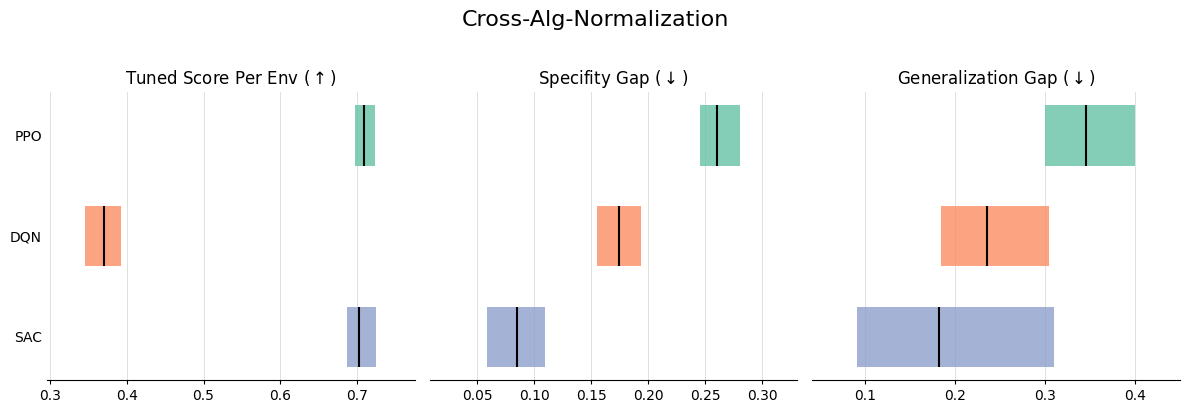

In [10]:
metrics = {}

for alg in algos:
    alg_subset = data[data["algorithm"]==alg]
    alg_performances = get_performance_arrays(alg_subset, perf_col="normed_performance")
    
    tspe_stats = bootstrap_metric(alg_performances, tuned_score_per_env, n_bootstrap=100, seed=42)
    phi_stats = bootstrap_metric(alg_performances, adkins_phi, n_bootstrap=100, seed=42)
    transfer_metric_stats = bootstrap_metric(alg_performances, transfer_metric, n_bootstrap=100, seed=42)

    metrics[alg] = {
        "tuned_score_per_env": tspe_stats,
        "Specifity_gap": phi_stats,
        "generalization_gap": transfer_metric_stats,
    }

plot_data = []
for alg, alg_metrics in metrics.items():
    for metric_name, stats in alg_metrics.items():
        plot_data.append({
            "algorithm": alg,
            "metric": metric_name,
            "mean": stats["mean"],
            "lower_ci": stats["lower_ci"],
            "upper_ci": stats["upper_ci"]
        })

plot_df = pd.DataFrame(plot_data)

plot_(plot_df, title_="Cross-Alg-Normalization")



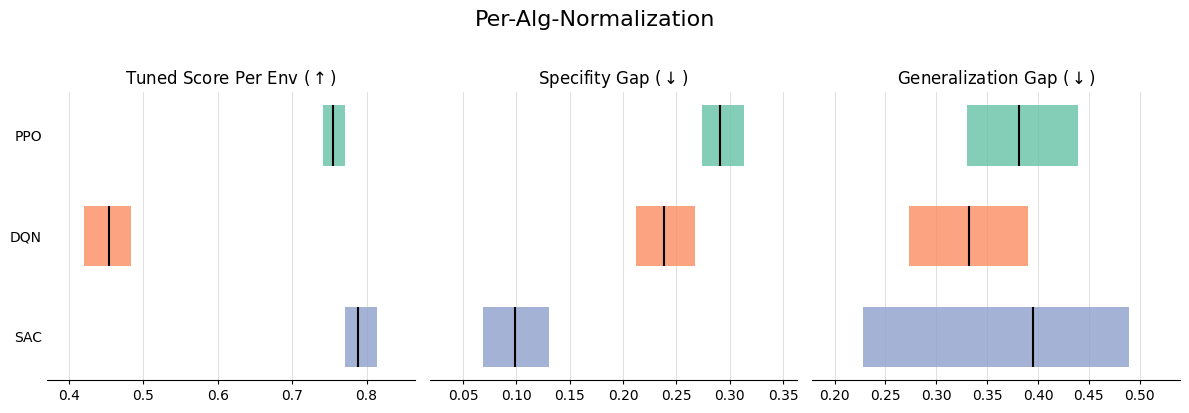

In [11]:
metrics = {}

for alg in algos:
    alg_subset = data[data["algorithm"]==alg]
    alg_performances = get_performance_arrays(alg_subset, perf_col="normed_performance_per_alg")
    
    tspe_stats = bootstrap_metric(alg_performances, tuned_score_per_env, n_bootstrap=100, seed=42)
    phi_stats = bootstrap_metric(alg_performances, adkins_phi, n_bootstrap=100, seed=42)
    transfer_metric_stats = bootstrap_metric(alg_performances, transfer_metric, n_bootstrap=100, seed=42)

    metrics[alg] = {
        "tuned_score_per_env": tspe_stats,
        "Specifity_gap": phi_stats,
        "generalization_gap": transfer_metric_stats,
    }

plot_data = []
for alg, alg_metrics in metrics.items():
    for metric_name, stats in alg_metrics.items():
        plot_data.append({
            "algorithm": alg,
            "metric": metric_name,
            "mean": stats["mean"],
            "lower_ci": stats["lower_ci"],
            "upper_ci": stats["upper_ci"]
        })

plot_df = pd.DataFrame(plot_data)

plot_(plot_df, title_="Per-Alg-Normalization")

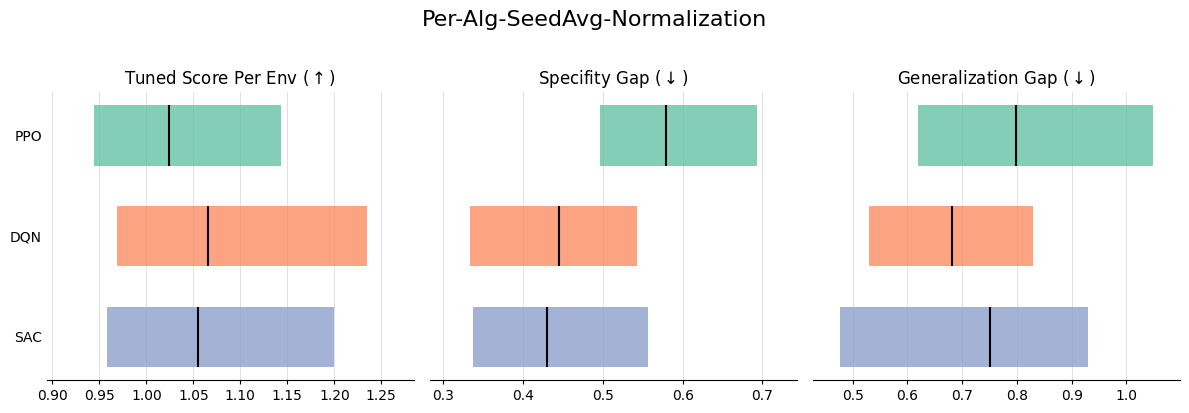

In [12]:
metrics = {}

for alg in algos:
    alg_subset = data[data["algorithm"]==alg]
    alg_performances = get_performance_arrays(alg_subset, perf_col="normed_performance_per_alg_seedavg")
    
    tspe_stats = bootstrap_metric(alg_performances, tuned_score_per_env, n_bootstrap=100, seed=42)
    phi_stats = bootstrap_metric(alg_performances, adkins_phi, n_bootstrap=100, seed=42)
    transfer_metric_stats = bootstrap_metric(alg_performances, transfer_metric, n_bootstrap=100, seed=42)

    metrics[alg] = {
        "tuned_score_per_env": tspe_stats,
        "Specifity_gap": phi_stats,
        "generalization_gap": transfer_metric_stats,
    }

plot_data = []
for alg, alg_metrics in metrics.items():
    for metric_name, stats in alg_metrics.items():
        plot_data.append({
            "algorithm": alg,
            "metric": metric_name,
            "mean": stats["mean"],
            "lower_ci": stats["lower_ci"],
            "upper_ci": stats["upper_ci"]
        })

plot_df = pd.DataFrame(plot_data)

plot_(plot_df, title_="Per-Alg-SeedAvg-Normalization")
